## Genome Instability Signatures — `14_OmicsGlobalSignatures.csv`

3,021 rows of whole-genome instability scores: MSI (microsatellite instability), CIN (chromosomal instability), ploidy, aneuploidy, and whole-genome doubling (WGD). Only available for cell lines with WGS data — ~14.5% of rows have NaN in all 6 scores. Filter `IsDefaultEntryForModel == 'Yes'` and join to other files via `ModelID`.

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
df = pd.read_csv(ini.df14)

In [3]:
df

,Unnamed: 0,SequencingID,ModelID,ModelConditionID,IsDefaultEntryForModel,IsDefaultEntryForMC,MSIScore,LoHFraction,WGD,CIN,Ploidy,Aneuploidy
0,0,CDS-00Nrci,ACH-000839,MC-000839-krru,Yes,Yes,3.68,0.107443,1.0,0.502634,3.158291,20.0
1,1,CDS-051xn7,ACH-000041,MC-000041-uPBf,Yes,Yes,2.21,0.130089,1.0,0.523865,3.236089,19.0
2,2,CDS-099jzP,ACH-002046,MC-002046-oaX8,Yes,Yes,2.87,0.222342,1.0,0.679772,3.326715,30.0
3,3,CDS-0A4mDu,ACH-002048,MC-002048-52d6,Yes,Yes,2.48,NaN,NaN,NaN,NaN,NaN
4,4,CDS-0Eax8o,ACH-000042,MC-000042-eOnX,Yes,Yes,2.07,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3016,3016,CDS-zuxWuZ,ACH-001622,MC-001622-QSPg,No,No,4.01,NaN,NaN,NaN,NaN,NaN
3017,3017,CDS-zvEfPE,ACH-001379,MC-001379-q3xU,Yes,Yes,3.78,0.180697,0.0,0.572390,2.586749,24.0
3018,3018,CDS-zvvAOM,ACH-001690,MC-001690-yWll,Yes,Yes,2.84,0.171637,1.0,0.510565,3.479860,22.0
3019,3019,CDS-zyxdAN,ACH-002225,MC-002225-0ukX,Yes,Yes,0.77,0.237493,1.0,0.726200,3.307654,22.0


### Load and clean
Drop the auto-index column and keep only the default entry per cell line to avoid double-counting.

In [4]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df_def = df[df["IsDefaultEntryForModel"] == "Yes"].copy()
print(f"All rows: {len(df)}  |  Default-only rows: {len(df_def)}")


All rows: 3021  |  Default-only rows: 1955


### Missing value analysis
WGS-only scores (LoHFraction, WGD, CIN, Ploidy, Aneuploidy) are NaN for cell lines that only have exome or RNA sequencing.

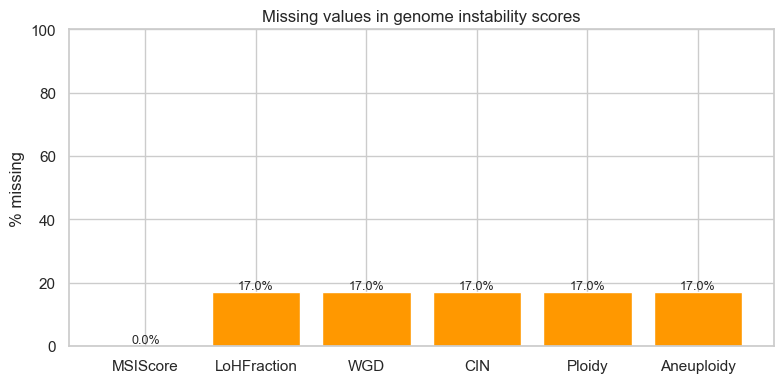

In [5]:
score_cols = ["MSIScore", "LoHFraction", "WGD", "CIN", "Ploidy", "Aneuploidy"]
pct_missing = df_def[score_cols].isnull().mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(score_cols, pct_missing, color=["#4CAF50" if v < 5 else "#FF9800" for v in pct_missing])
ax.set_ylabel("% missing"); ax.set_title("Missing values in genome instability scores")
ax.set_ylim(0, 100)
for bar, v in zip(bars, pct_missing):
    ax.text(bar.get_x() + bar.get_width()/2, v+1, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


### Individual score distributions
Each score captures a different axis of genomic chaos. These are cancer lines, so values sit above a healthy-diploid baseline: observed medians are MSIScore 2.19 (range 0.3-93), Ploidy 2.97, CIN 0.53, with whole-genome doubling in the majority (WGD median 1). Read each distribution against these cancer-panel medians, not a normal-cell anchor.

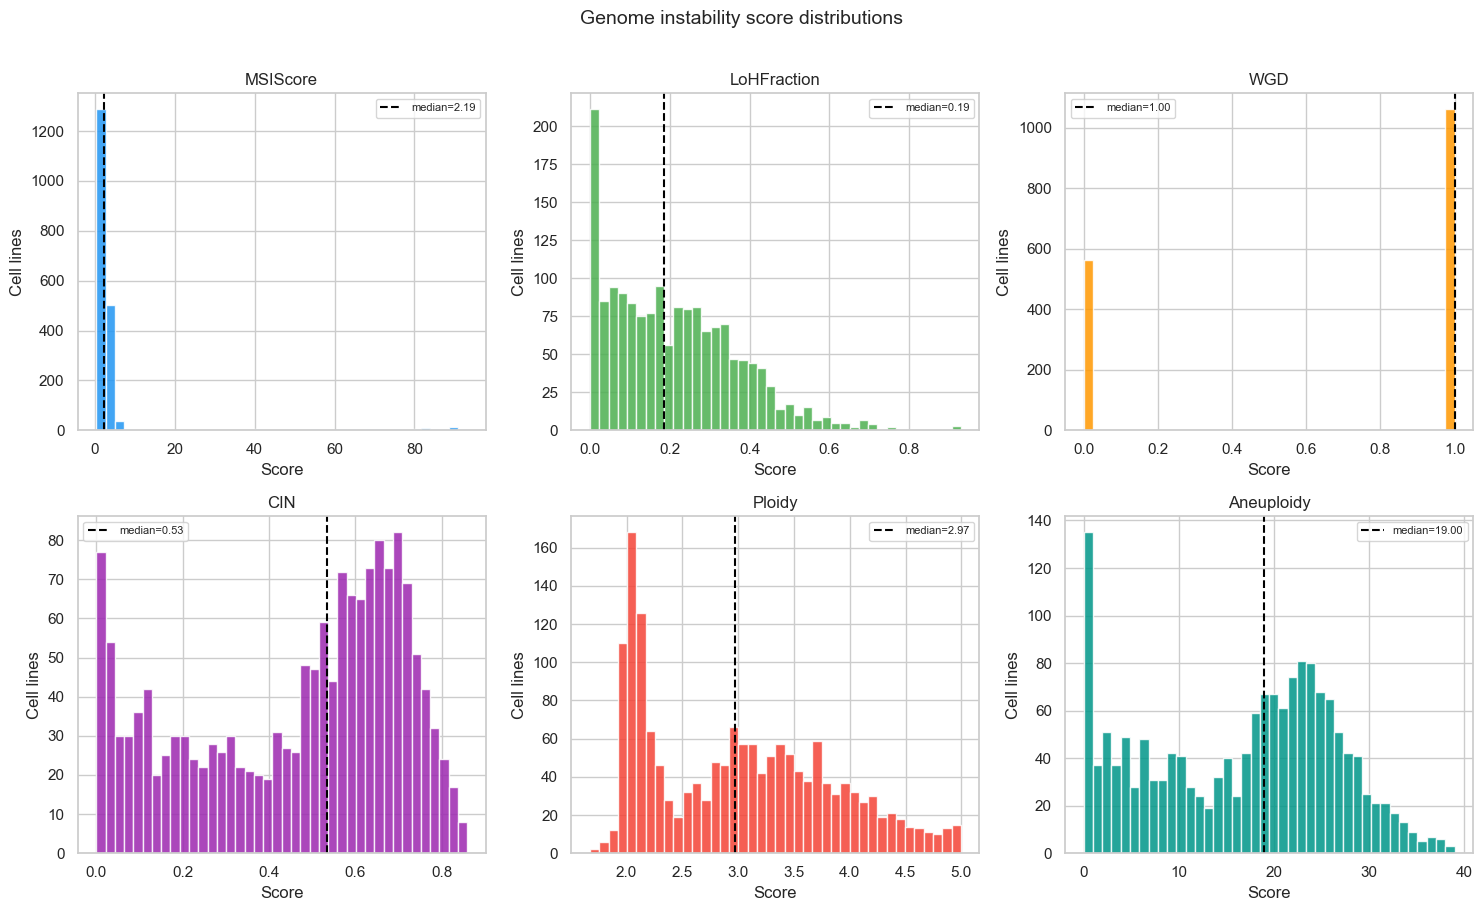

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336", "#009688"]

for ax, col, color in zip(axes, score_cols, colors):
    data = df_def[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.median(), color="black", linestyle="--", label=f"median={data.median():.2f}")
    ax.set_title(col); ax.set_xlabel("Score"); ax.set_ylabel("Cell lines")
    ax.legend(fontsize=8)

plt.suptitle("Genome instability score distributions", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### Whole-genome doubling (WGD)
WGD is binary: 1 means the cell line has doubled its entire genome at some point — common in cancer and affects drug sensitivity.

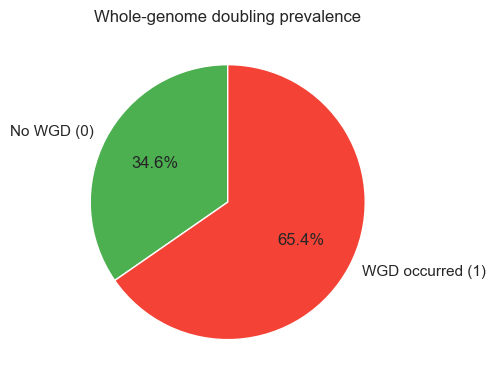

In [7]:
wgd_counts = df_def["WGD"].dropna().astype(int).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(wgd_counts.values,
       labels=["No WGD (0)", "WGD occurred (1)"],
       autopct="%1.1f%%", startangle=90, colors=["#4CAF50", "#F44336"])
ax.set_title("Whole-genome doubling prevalence")
plt.tight_layout(); plt.show()


### CIN vs Aneuploidy — are they redundant?
Both measure genomic instability but from different angles. A high Pearson r would mean one can be dropped.

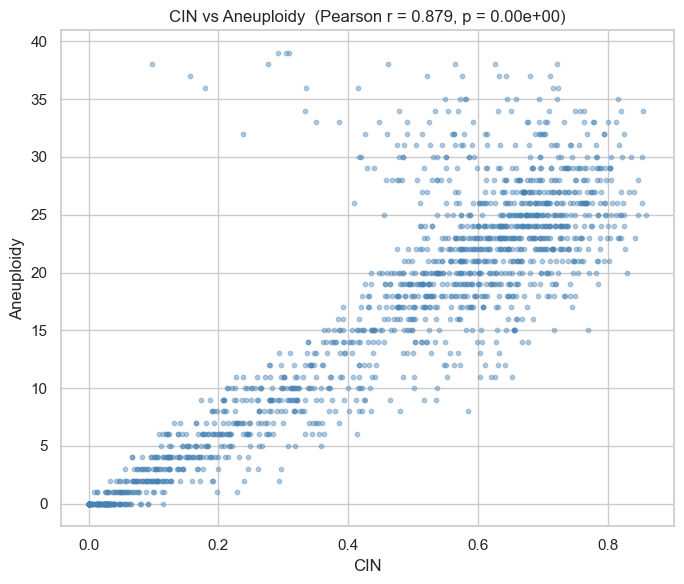

Pearson r = 0.879  (correlation between CIN and Aneuploidy)


In [8]:
pair = df_def[["CIN", "Aneuploidy"]].dropna()
r, p = stats.pearsonr(pair["CIN"], pair["Aneuploidy"])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pair["CIN"], pair["Aneuploidy"], alpha=0.4, s=10, color="steelblue")
ax.set_xlabel("CIN"); ax.set_ylabel("Aneuploidy")
ax.set_title(f"CIN vs Aneuploidy  (Pearson r = {r:.3f}, p = {p:.2e})")
plt.tight_layout(); plt.show()
print(f"Pearson r = {r:.3f}  (correlation between CIN and Aneuploidy)")


### Pairwise correlation of all 6 signature scores
Shows which scores are redundant and which provide independent signal.

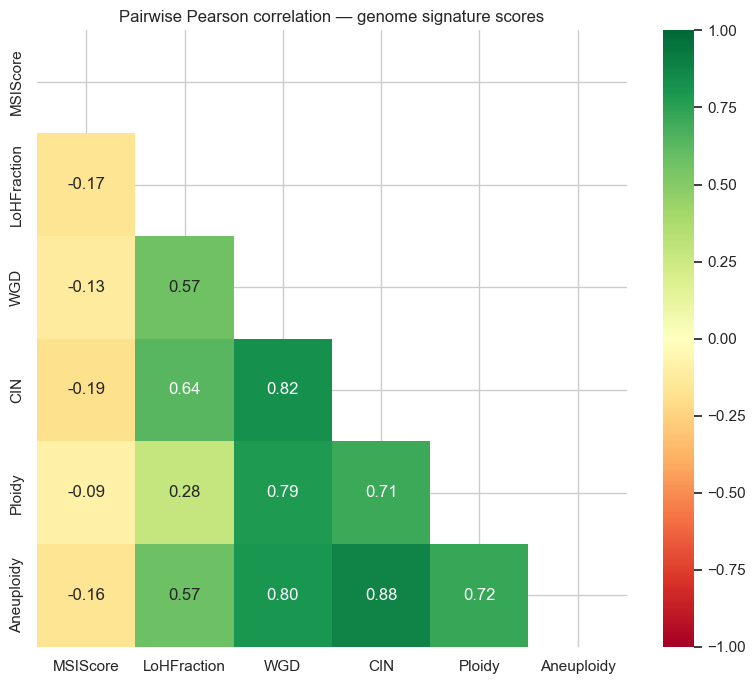

In [9]:
corr = df_def[score_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            vmin=-1, vmax=1, ax=ax, mask=mask)
ax.set_title("Pairwise Pearson correlation — genome signature scores")
plt.tight_layout(); plt.show()


### Key findings

In [10]:
wgs_avail = df_def["LoHFraction"].notna().sum()
print("=== Genome-wide Instability Signatures ===")
print(f"Default-entry rows            : {len(df_def)}")
print(f"Rows with WGS scores          : {wgs_avail}  ({wgs_avail/len(df_def)*100:.1f}%)")
print(f"WGD rate (of WGS lines)       : {(df_def['WGD']==1).sum()} / {df_def['WGD'].notna().sum()}  = {(df_def['WGD']==1).mean()*100:.1f}%")
print(f"CIN / Aneuploidy Pearson r    : {r:.3f}  → consider dropping one")
print(f"Median Ploidy                 : {df_def['Ploidy'].median():.2f}  (diploid = 2.0)")


=== Genome-wide Instability Signatures ===
Default-entry rows            : 1955
Rows with WGS scores          : 1622  (83.0%)
WGD rate (of WGS lines)       : 1060 / 1622  = 54.2%
CIN / Aneuploidy Pearson r    : 0.879  → consider dropping one
Median Ploidy                 : 2.97  (diploid = 2.0)


## Join Analysis — how this table connects to the others

df14 uses `ModelID` directly — the same canonical key as df9. Single-hop join.
It also links naturally to df2 (RNA) and df5 (fusions) via ModelID.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df14 | `ModelID` | df9 | `DepMap_ID` | many:1 | (default-entry: 1:1) |
| df14 via df9 | ModelID | df2 via df8 | ModelID | 1:1 | genome sigs + RNA |
| df14 via df9 | ModelID | df5 | `ModelID` | 1:many | genome sigs + fusions |
| df14 via df9 | ModelID | df6 via df8 | ModelID | 1:many | genome sigs + mutations |

**Biological note:** Genome instability scores are only computed for cell lines with
WGS data. Cell lines that only have WES are missing all 6 scores (NaN). Joining
df14 to df2 for a combined RNA + instability model will lose all non-WGS lines.


In [11]:
# ── A/B: Join coverage df14 → df9 and cross-datasets ────────────────────────
df9_ids   = pd.read_csv(ini.df9, usecols=["DepMap_ID","lineage"])
df8_ids   = pd.read_csv(ini.df8, usecols=["ProfileID","ModelID","Datatype"])

# Use default-entry rows only (as per EDA)
df_def = df[df["IsDefaultEntryForModel"] == "Yes"]
df14_models = set(df_def["ModelID"].dropna())
df9_models  = set(df9_ids["DepMap_ID"])
matched     = df14_models & df9_models
lost_df14   = df14_models - df9_models

# WGS-only models (have LoHFraction data)
wgs_models = set(df_def[df_def["LoHFraction"].notna()]["ModelID"])

# Cross-dataset overlaps
rna_models  = set(df8_ids[df8_ids.Datatype=="rna"]["ModelID"])
fus_models  = set(pd.read_csv(ini.df5, usecols=["ModelID"])["ModelID"].dropna())

print("=== df14 join: ModelID → df9 ===")
print(f"df14 default-entry ModelIDs  : {len(df14_models)}")
print(f"Matched in df9               : {len(matched)} ({len(matched)/len(df14_models)*100:.1f}%)")
print(f"Lost (not in df9)            : {len(lost_df14)}")
print()
print(f"WGS lines (full instability data): {len(wgs_models)}")
print(f"Non-WGS (missing scores)         : {len(matched) - len(wgs_models & matched)}")
print()
print(f"df14 models also in df2 (RNA)    : {len(matched & rna_models)}")
print(f"df14 models also in df5 (fusions): {len(matched & fus_models)}")
print(f"Triple: df14 + RNA + fusions     : {len(matched & rna_models & fus_models)}")


=== df14 join: ModelID → df9 ===
df14 default-entry ModelIDs  : 1955
Matched in df9               : 1704 (87.2%)
Lost (not in df9)            : 251

WGS lines (full instability data): 1622
Non-WGS (missing scores)         : 288

df14 models also in df2 (RNA)    : 1371
df14 models also in df5 (fusions): 1386
Triple: df14 + RNA + fusions     : 1370


In [12]:
# ── C: Format check on ModelID in df14 ──────────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df_def["ModelID"].dropna(), "ModelID (df14)", prefix="ACH-")
print()
# SequencingID format check
fmt_check(df_def["SequencingID"].dropna(), "SequencingID (df14)", prefix="CDS-")


Format check — ModelID (df14) (n=1955 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 0

Format check — SequencingID (df14) (n=1955 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CDS-'  : True
  Length range        : 10 – 10
  Duplicates          : 0


### Biological implications

Only WGS-sequenced cell lines have genome instability scores. If the pipeline uses
genome signatures as features, it is limited to the WGS subset — which may be
skewed towards certain cancer types (the ones DepMap prioritised for WGS).

Joining df14 to df2 (RNA) for a combined model: the intersection is the set of
cell lines with BOTH RNA expression AND genome instability data — check per-lineage
coverage to ensure no cancer types are systematically excluded.


In [13]:
# Biological: per-lineage WGS coverage
sig_df9 = df9_ids[df9_ids["DepMap_ID"].isin(matched)]
wgs_df9 = df9_ids[df9_ids["DepMap_ID"].isin(wgs_models & matched)]
non_wgs = df9_ids[df9_ids["DepMap_ID"].isin(matched - wgs_models)]

total_per = df9_ids["lineage"].value_counts()
sig_per   = sig_df9["lineage"].value_counts()
wgs_per   = wgs_df9["lineage"].value_counts()
pct_wgs   = (wgs_per / sig_per * 100).dropna().sort_values()

print("WGS coverage % per lineage (% of that lineage with full instability scores, lowest first):")
print(pct_wgs.head(10).round(1).to_string())
print()
print("Lineages with least WGS coverage (most data will be imputed/dropped):")
print(non_wgs["lineage"].value_counts().head(10).to_string())


WGS coverage % per lineage (% of that lineage with full instability scores, lowest first):
lineage
uterus                       65.0
ovary                        70.0
peripheral_nervous_system    72.0
breast                       75.0
colorectal                   75.6
gastric                      76.6
bile_duct                    76.7
pancreas                     76.8
kidney                       78.8
central_nervous_system       80.4

Lineages with least WGS coverage (most data will be imputed/dropped):
lineage
lung                         41
ovary                        21
central_nervous_system       20
colorectal                   19
breast                       17
blood                        17
lymphocyte                   15
uterus                       14
peripheral_nervous_system    14
pancreas                     13


## Deeper dive: MSI-high cutoff and resolving the CIN/Aneuploidy redundancy

Two concrete preprocessing decisions: (1) `MSIScore` is fully populated, so it is a
usable feature for every line - apply the standard clinical MSI-high cutoff (~>=20) to
get a binary biomarker; (2) `CIN` and `Aneuploidy` are strongly correlated, so one is
redundant - keep `CIN` (continuous, more granular) and drop `Aneuploidy`.

MSIScore missing            : 0.0% (fully populated)
MSI-high (>=20)             : 112 / 1955 (5.7%)
CIN vs Aneuploidy Pearson r : 0.879  -> redundant; keep CIN, drop Aneuploidy


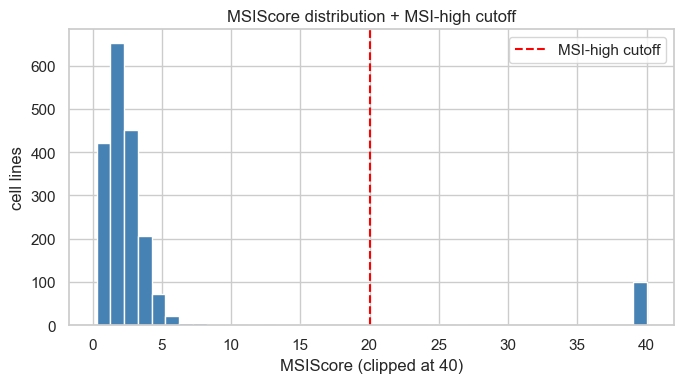

In [14]:
r = np.corrcoef(df_def[["CIN","Aneuploidy"]].dropna().T.values)[0,1]
hi = (df_def["MSIScore"] >= 20)
print(f"MSIScore missing            : {df_def['MSIScore'].isna().mean()*100:.1f}% (fully populated)")
print(f"MSI-high (>=20)             : {int(hi.sum())} / {len(df_def)} ({hi.mean()*100:.1f}%)")
print(f"CIN vs Aneuploidy Pearson r : {r:.3f}  -> redundant; keep CIN, drop Aneuploidy")
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(df_def["MSIScore"].clip(upper=40), bins=40, color="steelblue", edgecolor="white")
ax.axvline(20, color="red", ls="--", label="MSI-high cutoff")
ax.set_xlabel("MSIScore (clipped at 40)"); ax.set_ylabel("cell lines"); ax.legend()
ax.set_title("MSIScore distribution + MSI-high cutoff")
plt.tight_layout(); plt.show()

## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
Instead of measuring individual genes, this file gives a handful of **"genome chaos scores"** — summary numbers describing **how scrambled a cell's DNA is overall**. In plain terms: Is its spell-checker broken (**MSI**)? Has it lost backup copies of genes (**LoH**)? Did it accidentally double its entire genome (**WGD**)? Are its chromosomes a mess (**CIN** / **Aneuploidy**)? How many chromosome sets does it carry (**Ploidy**)? These are classic **hallmarks of how advanced/aggressive a cancer is**, summarised in just 6 numbers per cell line.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- **1,955 cell lines** (after keeping default entries) × 6 score columns, keyed by `ModelID`.
- **`MSIScore` is 100% filled**; the other 5 scores are **~17% missing as a block** because they require whole-genome sequencing (WGS), which not every line has.
- **WGD (genome doubling) affects ~54%** of lines; median ploidy ~3 (cancers often carry extra chromosome sets).
- **`CIN` and `Aneuploidy` are ~0.88 correlated** — they measure nearly the same thing, so one is redundant.

Next steps (preprocessing):
- **Filter to `IsDefaultEntryForModel == 'Yes'`** (removes duplicate runs).
- **Join via `ModelID`** to the master catalogue.
- **Apply the clinical MSI cutoff** (`MSIScore ≥ 20` → "MSI-high" flag).
- **Drop `Aneuploidy`, keep `CIN`** (drop the redundant twin).
- **Flag the WGS-only missing block** rather than blindly imputing it (the missingness is itself informative: "this line wasn't whole-genome sequenced").

Still missing in EDA: nothing major — decide the imputation/flag rule for non-WGS lines and move on.

### 3. Which ML approach fits this dataset
**Supervised — compact, interpretable features.** Just 6 (soon 5) clean numbers per line that are easy to explain ("selected because it's MSI-high with high chromosomal instability"). These are some of the strongest **"why this cell line"** signals in the whole project.

> **Big-picture note:** Genome signatures are one of the four **core layers** on the DepMap spine (with RNA, fusions, and mutations) that define the ~1,400-line training core.